In [1]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Task 1. Image and bounding box concept

In [12]:
image_path = 'image2.jpg'
img = Image.open(image_path).convert("RGB")

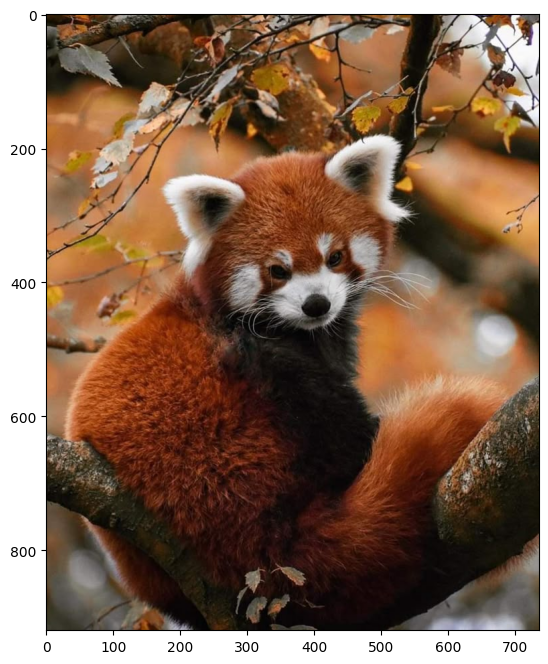

In [16]:
# Отрисовка
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(img)

In [17]:
manual_bbox = [150, 250, 450, 500] # Твои координаты
rect = patches.Rectangle((manual_bbox[0], manual_bbox[1]),
                         manual_bbox[2], manual_bbox[3],
                         linewidth=2, edgecolor='r', facecolor='none',
                         label='Manual Box')

In [18]:
ax.add_patch(rect)

In [19]:
ax.legend()

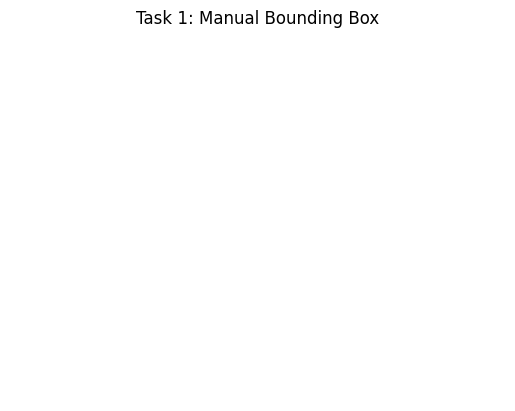

In [20]:
plt.title("Task 1: Manual Bounding Box")
plt.axis('off')
plt.show()

In [21]:
print(f"Manual Bounding Box coordinates (x, y, width, height): {manual_bbox}")

Manual Bounding Box coordinates (x, y, width, height): [150, 250, 450, 500]


# Task 2. Object detection using a pretrained detector

In [22]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.eval() # Переводим модель в режим оценки

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 147MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [23]:
# Получаем классы (например, "человек", "машина", "собака")
categories = weights.meta["categories"]

In [24]:
# Подготавливаем изображение для модели (превращаем в тензор)
img_tensor = F.to_tensor(img).unsqueeze(0)

In [25]:
# Делаем предсказание
with torch.no_grad():
    predictions = model(img_tensor)[0]

In [28]:
def plot_predictions(image, preds, threshold=0.5, title="Detection Results"):
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(image)

    count = 0
    for i in range(len(preds['scores'])):
        score = preds['scores'][i].item()
        if score > threshold:
            count += 1
            box = preds['boxes'][i].numpy() # Формат: [x_min, y_min, x_max, y_max]
            label_id = preds['labels'][i].item()
            label_name = categories[label_id]

            # Рисуем рамку
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor='g', facecolor='none')
            ax.add_patch(rect)

            # Добавляем текст (Класс + Уверенность)
            ax.text(box[0], box[1]-5, f'{label_name}: {score:.2f}',
                    color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.5))

    plt.title(f"{title} (Threshold: {threshold})")
    plt.axis('off')
    plt.show()
    return count

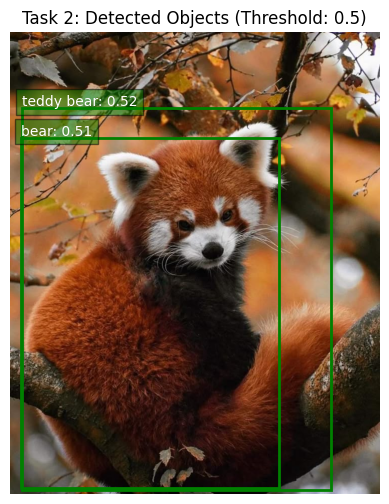

Number of detected objects (Confidence > 0.5): 2


In [29]:
# Выводим результаты со стандартным порогом (0.5)
detected_count = plot_predictions(img, predictions, threshold=0.5, title="Task 2: Detected Objects")
print(f"Number of detected objects (Confidence > 0.5): {detected_count}")

# Task 3. Confidence threshold analysis

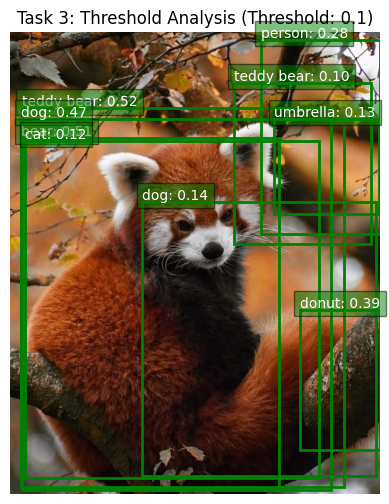

Threshold 0.1: Detected 9 objects.


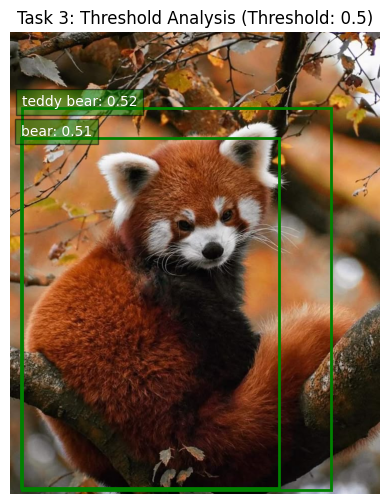

Threshold 0.5: Detected 2 objects.


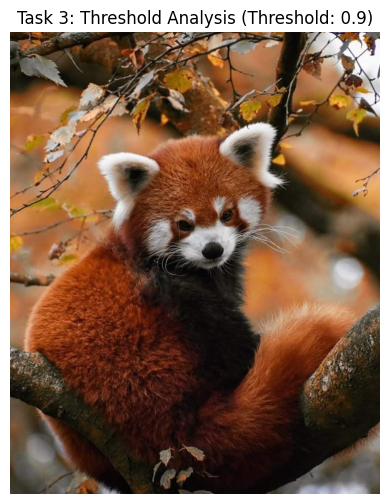

Threshold 0.9: Detected 0 objects.


In [30]:
thresholds = [0.1, 0.5, 0.9]

for t in thresholds:
    count = plot_predictions(img, predictions, threshold=t, title="Task 3: Threshold Analysis")
    print(f"Threshold {t}: Detected {count} objects.")

# Task 4. Intersection over Union (IoU)

In [31]:
def calculate_iou(box1, box2):
    # box1 и box2 должны быть в формате [x_min, y_min, x_max, y_max]
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [32]:
# Конвертируем наш ручной бокс из [x, y, w, h] в [x_min, y_min, x_max, y_max]
manual_box_converted = [
    manual_bbox[0],
    manual_bbox[1],
    manual_bbox[0] + manual_bbox[2],
    manual_bbox[1] + manual_bbox[3]
]

In [33]:
# Берем самый уверенный предсказанный бокс из Task 2 (он первый в списке)
best_predicted_box = predictions['boxes'][0].numpy()

In [34]:
iou_score = calculate_iou(manual_box_converted, best_predicted_box)

In [35]:
print(f"Manual Box [x1, y1, x2, y2]: {manual_box_converted}")
print(f"Predicted Box [x1, y1, x2, y2]: {best_predicted_box}")
print(f"IoU Score: {iou_score:.4f}")

Manual Box [x1, y1, x2, y2]: [150, 250, 600, 750]
Predicted Box [x1, y1, x2, y2]: [ 23.45388 151.76659 638.6509  910.72125]
IoU Score: 0.4819
